# 08 · Reproducibility — Cheap vs Flagship (a disciplined vibe-check)

**The claim we want to test:** a *cheap* reasoning model (**DeepSeek V4 Pro**, `deepseek-v4-pro`) can **match a flagship** (Claude Opus 4.8 / GPT-5.5) on a **specific narrow task** — at a fraction of the cost.

**The discipline we add to the vibe-check:** a fixed eval set, an LLM-as-judge, fixed seeds, and `temperature=0`, so the comparison is *repeatable* rather than anecdotal.

> **Punchline for students:** don't reflexively reach for the most expensive model. Pick **per task**, and turn your "vibe check" into something you can re-run tomorrow and get (nearly) the same answer.

---

This notebook reuses the model registry, provider adapters, and the LLM-as-judge from **`07_picking_a_reasoning_model_for_an_application.ipynb`**, and borrows the **mock-mode** idea from its `v2_codex` variant so the whole thing runs **with no API keys at all**.

| | |
|---|---|
| **Cheap model** | `deepseek-v4-pro` (OpenAI-compatible chat, `seed=` supported) |
| **Flagship** | `claude-opus-4.8` (preferred) → falls back to `gpt-5.5` |
| **Eval set** | 10 self-contained reasoning prompts with reference answers |
| **Judge** | OpenAI → Anthropic → keyword fallback (same as 07) |
| **Runs with no keys?** | **Yes** — deterministic seeded mock mode |

## 0 · Setup & environment

```bash
uv pip install openai anthropic pandas matplotlib numpy python-dotenv
```

Keys go in a `.env` file (only the ones you have — everything else is mocked):

```
OPENAI_API_KEY=...
ANTHROPIC_API_KEY=...
DEEPSEEK_API_KEY=...
```

In [1]:
import os, json, time, random, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

# ---------------------------------------------------------------- SEED everything
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def have(*names):
    """Return the first non-empty env var among names (or None)."""
    for n in names:
        v = os.environ.get(n)
        if v:
            return v
    return None

print("-" * 60)
print("Keys detected:")
for label, names in [
    ("OpenAI",   ["OPENAI_API_KEY"]),
    ("Anthropic",["ANTHROPIC_API_KEY"]),
    ("DeepSeek", ["DEEPSEEK_API_KEY"]),
]:
    print(f"  {label:10s}: {'set' if have(*names) else '-- missing (will MOCK)'}")
print("-" * 60)
print(f"Global SEED = {SEED}  (random + numpy seeded)")

------------------------------------------------------------
Keys detected:
  OpenAI    : set
  Anthropic : set
  DeepSeek  : -- missing (will MOCK)
------------------------------------------------------------
Global SEED = 42  (random + numpy seeded)


## 1 · Model registry (reused from notebook 07)

Same registry shape as `07`: each entry says which API style it uses, the model id, the base URL (for OpenAI-compatible endpoints), and which env var holds the key. We only need three of the five models here, but we keep the full registry so you can swap contenders freely.

In [2]:
MODELS = {
    "gpt-5.5": {
        "label": "GPT-5.5",
        "kind": "openai_responses",
        "model_id": "gpt-5.5",
        "keys": ["OPENAI_API_KEY"],
    },
    "claude-opus-4.8": {
        "label": "Claude Opus 4.8",
        "kind": "anthropic",
        "model_id": "claude-opus-4-8",
        "keys": ["ANTHROPIC_API_KEY"],
    },
    "deepseek-v4-pro": {
        "label": "DeepSeek V4 Pro",
        "kind": "chat",                       # OpenAI-compatible
        "model_id": "deepseek-v4-pro",
        "base_url": "https://api.deepseek.com",
        "keys": ["DEEPSEEK_API_KEY"],
    },
}

ACTIVE = [k for k, s in MODELS.items() if have(*s["keys"])]
print("Models with a live key:", ACTIVE or "(none -- everything runs in MOCK mode)")

# ---------------------------------------------------------------- the matchup
CHEAP_KEY = "deepseek-v4-pro"
# Prefer Opus 4.8 as the flagship; fall back to GPT-5.5 if only that key is present
# (and fall back to it anyway in pure-mock mode so the story is consistent).
if have(*MODELS["claude-opus-4.8"]["keys"]):
    FLAGSHIP_KEY = "claude-opus-4.8"
elif have(*MODELS["gpt-5.5"]["keys"]):
    FLAGSHIP_KEY = "gpt-5.5"
else:
    FLAGSHIP_KEY = "claude-opus-4.8"   # mock default

CONTENDERS = [CHEAP_KEY, FLAGSHIP_KEY]
print(f"Cheap contender : {MODELS[CHEAP_KEY]['label']}  ({CHEAP_KEY})")
print(f"Flagship        : {MODELS[FLAGSHIP_KEY]['label']}  ({FLAGSHIP_KEY})")

Models with a live key: ['gpt-5.5', 'claude-opus-4.8']
Cheap contender : DeepSeek V4 Pro  (deepseek-v4-pro)
Flagship        : Claude Opus 4.8  (claude-opus-4.8)


## 2 · Cost table — **editable 2026 placeholder estimates**

These are **illustrative** USD prices per **million tokens** (input / output). They are *not* live pricing — update them from each provider's pricing page on the day you run a real comparison. They exist so the notebook can compute an *estimated* cost per prompt.

In [3]:
# !!! EDITABLE PLACEHOLDER PRICING -- replace with real numbers before any real decision.
COST_PER_MTOK = {
    # model_key            input $/Mtok   output $/Mtok
    "gpt-5.5":          {"in": 2.50, "out": 15.00},
    "claude-opus-4.8":  {"in": 5.00, "out": 25.00},
    "deepseek-v4-pro":  {"in": 0.28, "out": 0.42},   # ~10-50x cheaper -- the whole point
}

def estimate_cost(model_key, in_tokens, out_tokens):
    p = COST_PER_MTOK[model_key]
    return (in_tokens / 1e6) * p["in"] + (out_tokens / 1e6) * p["out"]

print("Placeholder pricing (USD per million tokens) -- EDIT THESE:")
print("-" * 60)
for k in CONTENDERS:
    p = COST_PER_MTOK[k]
    print(f"  {MODELS[k]['label']:18s}  in=${p['in']:>6.2f}/Mtok   out=${p['out']:>6.2f}/Mtok")
print("-" * 60)
ratio = (COST_PER_MTOK[FLAGSHIP_KEY]['out'] / COST_PER_MTOK[CHEAP_KEY]['out'])
print(f"Headline output-price ratio (flagship / cheap): ~{ratio:.0f}x")

Placeholder pricing (USD per million tokens) -- EDIT THESE:
------------------------------------------------------------
  DeepSeek V4 Pro     in=$  0.28/Mtok   out=$  0.42/Mtok
  Claude Opus 4.8     in=$  5.00/Mtok   out=$ 25.00/Mtok
------------------------------------------------------------
Headline output-price ratio (flagship / cheap): ~60x


## 3 · The vibe-check task + a fixed eval set

**Task:** short, self-contained reasoning questions about reasoning-model / LLM-training concepts (the same subject matter as the `notes_dataset/` used in 07), each with a concise **reference answer**. This is exactly the kind of *narrow, well-specified* task where a cheap model often matches a flagship.

The eval set is a **fixed, ordered list** — we never shuffle it — which is one of the things that makes the comparison reproducible.

In [4]:
EVAL_SET = [
    {"id": "q01",
     "question": "In GRPO, how is the advantage for each completion computed, and which network does it remove compared to PPO?",
     "reference": "The advantage is group-relative: (reward - group mean) / group std over a sampled group of completions. It removes the value/critic network that PPO must train."},
    {"id": "q02",
     "question": "What problem do DAPO and Dr. GRPO both fix in GRPO?",
     "reference": "They both fix the length-normalization bias (the 1/|o| per-output factor) that makes the model prefer longer incorrect outputs. DAPO normalizes over total group tokens (plus clip-higher); Dr. GRPO drops the length term entirely."},
    {"id": "q03",
     "question": "How many stages are in the DeepSeek R1 training pipeline, and what is stage 2?",
     "reference": "Five stages. Stage 2 is cold-start SFT: a few thousand cleaned long chain-of-thought examples used as an anchor before RL."},
    {"id": "q04",
     "question": "What reward does DeepSeek R1-Zero use, and what two delimiters does its prompt template require?",
     "reference": "A verifiable format + accuracy reward (no learned reward model). The template puts reasoning in <think></think> and the final answer in <answer></answer>."},
    {"id": "q05",
     "question": "Give the two standard intuitions for why chain-of-thought helps.",
     "reference": "(1) Decomposition: splitting a hard problem into sub-problems reuses seen patterns. (2) More test-time compute: each emitted token is another forward pass, so more reasoning tokens buy more computation before answering."},
    {"id": "q06",
     "question": "Name two techniques for controlling a reasoning model's thinking budget.",
     "reference": "Any two of: dynamic budget routing, budget forcing ('Wait' to extend / 'time is up' to stop), context-aware budgeting, or continuous/latent thoughts (Coconut)."},
    {"id": "q07",
     "question": "Per the o1 prompting guidance, should you tell a reasoning model to 'think step by step', and what replaces system messages?",
     "reference": "No -- explicit 'think step by step' prompts are unnecessary and can hurt. Developer messages replace system messages for these models."},
    {"id": "q08",
     "question": "What does the GSM-Symbolic study conclude, including the effect of irrelevant information?",
     "reference": "LLM math reasoning is fragile and pattern-matching-like: accuracy varies with numeric changes and drops as clauses increase. Irrelevant info (GSM-NoOp) can cut performance by up to ~65%."},
    {"id": "q09",
     "question": "In R1-style reasoning distillation, is the student trained by logit matching or plain SFT, and how does it compare to RL-from-scratch at small scale?",
     "reference": "Plain SFT on the teacher's generated reasoning traces (not logit matching). At small scale, distillation beats RL-from-scratch (e.g. distilled Qwen-32B ~72.6 AIME vs ~47.0 from RL)."},
    {"id": "q10",
     "question": "What does the KL penalty enforce in RL fine-tuning, and where does the KL term live in PPO vs GRPO?",
     "reference": "It keeps the policy near a trusted reference (the SFT model). PPO folds KL into the per-token reward before advantage estimation; GRPO uses a separate explicit -beta*KL term in the objective."},
]

# Fix the order explicitly (reproducibility): sort by id, never shuffle.
EVAL_SET = sorted(EVAL_SET, key=lambda t: t["id"])
print(f"{len(EVAL_SET)} evaluation prompts (fixed order):")
for t in EVAL_SET:
    print(f"  {t['id']}: {t['question'][:70]}...")

10 evaluation prompts (fixed order):
  q01: In GRPO, how is the advantage for each completion computed, and which ...
  q02: What problem do DAPO and Dr. GRPO both fix in GRPO?...
  q03: How many stages are in the DeepSeek R1 training pipeline, and what is ...
  q04: What reward does DeepSeek R1-Zero use, and what two delimiters does it...
  q05: Give the two standard intuitions for why chain-of-thought helps....
  q06: Name two techniques for controlling a reasoning model's thinking budge...
  q07: Per the o1 prompting guidance, should you tell a reasoning model to 't...
  q08: What does the GSM-Symbolic study conclude, including the effect of irr...
  q09: In R1-style reasoning distillation, is the student trained by logit ma...
  q10: What does the KL penalty enforce in RL fine-tuning, and where does the...


## 4 · What is — and isn't — reproducible across hosted models

We pin everything we *can* control:

- **`temperature = 0`** (lowest / greedy decoding) for every provider that accepts it.
- **`seed=SEED`** passed to providers that accept it — OpenAI Responses and DeepSeek/OpenAI-compatible chat both take a `seed`. Anthropic does **not** expose a seed (and Opus 4.8 rejects an explicit `temperature`), so for Opus we rely on its **default greedy decoding** for determinism.
- **Python / NumPy seeds** fixed, and a **fixed eval-set order** (sorted by id, never shuffled).
- The **judge** also runs at `temperature=0` with low reasoning effort.

**Honest caveat:** hosted reasoning models are **not bit-exact**, even at `temperature=0` with a seed. Floating-point non-determinism, server-side batching, mixture-of-experts routing, and silent model updates all introduce variance. Seeds + a fixed eval set **reduce** run-to-run drift and make a comparison *defensible*; they do not make it *identical*. Treat the seed as "shrink the noise", not "eliminate it". The mock mode below, by contrast, **is** perfectly deterministic — useful precisely because it isolates the harness from provider noise.

## 5 · Provider adapters (live) — reused from 07, pinned to seed + temperature 0

These are the same single-shot adapters as in notebook 07, trimmed for this task (no `search_notes` tool — the prompts are self-contained) and **pinned for reproducibility**. They are only ever called when a real key is present; otherwise the mock path in §6 runs instead.

In [5]:
SYSTEM_PROMPT = (
    "You are a precise assistant answering questions about reasoning models and "
    "LLM training. Answer in 2-4 concise sentences. State the key facts directly."
)

# Build live clients only for models that actually have a key ------------------
CLIENTS = {}
_openai = None
if have("OPENAI_API_KEY"):
    from openai import OpenAI
    _openai = OpenAI()

for key in ACTIVE:
    spec = MODELS[key]
    kind = spec["kind"]
    if kind == "openai_responses":
        CLIENTS[key] = _openai
    elif kind == "anthropic":
        from anthropic import Anthropic
        CLIENTS[key] = Anthropic()
    elif kind == "chat":
        from openai import OpenAI
        CLIENTS[key] = OpenAI(api_key=have(*spec["keys"]), base_url=spec["base_url"])

print("Live clients built for:", list(CLIENTS) or "(none)")


# --- OpenAI Responses API (gpt-5.5) -- seed + low effort ---------------------
def run_openai(client, model_id, question):
    t0 = time.perf_counter()
    resp = client.responses.create(
        model=model_id, reasoning={"effort": "low"},
        temperature=0, seed=SEED,
        instructions=SYSTEM_PROMPT,
        input=[{"role": "user", "content": question}],
    )
    u = getattr(resp, "usage", None)
    return {"answer": resp.output_text or "",
            "latency_s": time.perf_counter() - t0,
            "in_tokens": getattr(u, "input_tokens", 0) or 0,
            "out_tokens": getattr(u, "output_tokens", 0) or 0,
            "error": None}


# --- Anthropic Messages -- no seed param; Opus 4.8 is greedy by default -------
# (Opus 4.8 rejects an explicit `temperature`, so we omit it and rely on the
#  model's default deterministic decoding -- see the reproducibility note above.)
def run_anthropic(client, model_id, question):
    t0 = time.perf_counter()
    resp = client.messages.create(
        model=model_id, max_tokens=1024,
        system=SYSTEM_PROMPT,
        messages=[{"role": "user", "content": question}],
    )
    text = "".join(b.text for b in resp.content if b.type == "text")
    u = getattr(resp, "usage", None)
    return {"answer": text,
            "latency_s": time.perf_counter() - t0,
            "in_tokens": getattr(u, "input_tokens", 0) or 0,
            "out_tokens": getattr(u, "output_tokens", 0) or 0,
            "error": None}


# --- OpenAI-compatible chat (DeepSeek) -- seed + temperature 0 ---------------
def run_chat(client, model_id, question):
    t0 = time.perf_counter()
    resp = client.chat.completions.create(
        model=model_id, temperature=0, seed=SEED,
        messages=[{"role": "system", "content": SYSTEM_PROMPT},
                  {"role": "user", "content": question}],
    )
    m = resp.choices[0].message
    u = getattr(resp, "usage", None)
    return {"answer": m.content or "",
            "latency_s": time.perf_counter() - t0,
            "in_tokens": getattr(u, "prompt_tokens", 0) or 0,
            "out_tokens": getattr(u, "completion_tokens", 0) or 0,
            "error": None}


_DISPATCH = {"openai_responses": run_openai, "anthropic": run_anthropic, "chat": run_chat}

def run_agent_live(model_key, question):
    spec = MODELS[model_key]
    try:
        return _DISPATCH[spec["kind"]](CLIENTS[model_key], spec["model_id"], question)
    except Exception as e:
        return {"answer": "", "latency_s": None, "in_tokens": 0, "out_tokens": 0,
                "error": f"{type(e).__name__}: {e}"[:300]}

print("Live adapters ready.")

Live clients built for: ['gpt-5.5', 'claude-opus-4.8']
Live adapters ready.


## 6 · MOCK mode — deterministic, no API keys required

If a contender has **no key**, we synthesize its results from a **seeded RNG** (SHA-256 over `model_key | qid | field`, exactly the trick the `07_v2_codex` notebook uses). This makes the whole notebook run top-to-bottom and renders every chart, while staying perfectly reproducible.

The mock **profiles** below encode the *story* we're teaching: the cheap model is a hair behind the flagship on quality, much faster, and dramatically cheaper. They are **illustrative teaching data, not benchmark claims.**

In [6]:
# Mock model profiles -- illustrative ONLY (teaching data, not a benchmark).
MOCK_PROFILES = {
    "deepseek-v4-pro":  {"answer_quality": 0.90, "base_latency_s": 1.6, "tok_scale": 1.00},
    "claude-opus-4.8":  {"answer_quality": 0.93, "base_latency_s": 3.4, "tok_scale": 1.15},
    "gpt-5.5":          {"answer_quality": 0.93, "base_latency_s": 2.6, "tok_scale": 1.10},
}

def stable_random(*parts):
    """Deterministic float in [0,1) from a string key (sha256)."""
    key = "|".join(str(p) for p in parts).encode("utf-8")
    return int(hashlib.sha256(key).hexdigest()[:12], 16) / float(16 ** 12)

def estimate_tokens(text):
    return max(1, len(text) // 4)

def run_agent_mock(model_key, task):
    prof = MOCK_PROFILES.get(model_key, {"answer_quality": 0.85, "base_latency_s": 2.0, "tok_scale": 1.0})
    qid = task["id"]
    answer_ok = stable_random(model_key, qid, "answer") <= prof["answer_quality"]
    if answer_ok:
        answer = task["reference"]
    else:
        answer = task["reference"].split(".")[0] + ". (details omitted / partially correct)"
    # deterministic latency jitter around the base
    jitter = (stable_random(model_key, qid, "latency") - 0.5) * 0.8
    latency = round(prof["base_latency_s"] * (1 + jitter), 3)
    in_tokens = int((estimate_tokens(SYSTEM_PROMPT + task["question"]) + 40) * prof["tok_scale"])
    out_tokens = int((estimate_tokens(answer) + 30) * prof["tok_scale"])
    return {"answer": answer, "latency_s": latency,
            "in_tokens": in_tokens, "out_tokens": out_tokens, "error": None}


# Track contenders whose live calls fail so we can fall back to mock gracefully.
_LIVE_FALLBACK = set()

def run_agent(model_key, task):
    """Live if the key is present and working; otherwise deterministic mock.

    If a live contender errors (e.g. a placeholder / unavailable model id), we
    fall back to the seeded mock for that model so the teaching narrative still
    runs end-to-end instead of collapsing to 0% accuracy.
    """
    if model_key in ACTIVE and model_key not in _LIVE_FALLBACK:
        out = run_agent_live(model_key, task["question"])
        if not out["error"] and out["answer"].strip():
            return out
        _LIVE_FALLBACK.add(model_key)
        print(f"  [warn] live calls for {MODELS[model_key]['label']} failed "
              f"({out['error']}); falling back to MOCK for this model.")
    return run_agent_mock(model_key, task)


# ---------------------------------------------------------------- mode policy
# Apples-to-apples rule: a live-vs-mock comparison is meaningless (a live model
# judged by a live judge vs deterministic mock data). So we only go LIVE when
# BOTH contenders have a working key; otherwise BOTH run in deterministic mock.
BOTH_HAVE_KEYS = all(k in ACTIVE for k in CONTENDERS)
FULLY_MOCK = not BOTH_HAVE_KEYS

# When not both keyed, force every contender down the mock path for consistency.
if FULLY_MOCK:
    ACTIVE = [k for k in ACTIVE if k not in CONTENDERS]

# ---------------------------------------------------------------- mode banner
print("=" * 60)
if FULLY_MOCK:
    missing = [MODELS[k]['label'] for k in CONTENDERS if k not in ACTIVE
               and not have(*MODELS[k]['keys'])]
    print("RUNNING IN FULL MOCK MODE (both contenders mocked).")
    if missing:
        print("  Reason: missing key(s) for:", missing)
    else:
        print("  Reason: not all contenders have a live key.")
    print("  All results are deterministic synthetic data from a seeded RNG,")
    print("  so the cheap-vs-flagship comparison stays apples-to-apples.")
else:
    print("RUNNING IN FULL LIVE MODE -- both contenders use real API calls.")
print("=" * 60)

RUNNING IN FULL MOCK MODE (both contenders mocked).
  Reason: missing key(s) for: ['DeepSeek V4 Pro']
  All results are deterministic synthetic data from a seeded RNG,
  so the cheap-vs-flagship comparison stays apples-to-apples.


## 7 · LLM-as-judge (reused from 07)

The judge scores each answer **0/1** against the reference. It uses OpenAI if available, else Anthropic, else a keyword-overlap fallback — so judging works in mock mode too. Judge calls are pinned to `temperature=0`.

In [7]:
JUDGE_INSTRUCTIONS = (
    "You are a strict grader. Given a QUESTION, a REFERENCE answer, and a CANDIDATE "
    "answer, return ONLY a JSON object: {\"correct\": 0 or 1}. Mark 1 only if the "
    "candidate captures the key facts of the reference. JSON only, no prose."
)

def _parse_json(text):
    text = text.strip()
    if "{" in text:
        text = text[text.index("{"): text.rindex("}") + 1]
    return json.loads(text)

def _keyword_correct(reference, answer):
    ref_words = {w.lower().strip(".,()") for w in reference.split() if len(w) > 4}
    ans_words = {w.lower().strip(".,()") for w in answer.split()}
    overlap = len(ref_words & ans_words) / max(1, len(ref_words))
    return int(overlap > 0.35)

def judge(question, reference, answer):
    if not answer or not answer.strip():
        return 0
    prompt = (f"QUESTION:\n{question}\n\nREFERENCE:\n{reference}\n\n"
              f"CANDIDATE:\n{answer}\n\nReturn the JSON now.")
    try:
        if have("OPENAI_API_KEY"):
            r = _openai.responses.create(
                model="gpt-5.5", reasoning={"effort": "low"},
                temperature=0, seed=SEED,
                instructions=JUDGE_INSTRUCTIONS,
                input=[{"role": "user", "content": prompt}])
            return int(_parse_json(r.output_text)["correct"])
        elif have("ANTHROPIC_API_KEY"):
            from anthropic import Anthropic
            r = Anthropic().messages.create(
                model="claude-opus-4-8", max_tokens=100, temperature=0,
                system=JUDGE_INSTRUCTIONS,
                messages=[{"role": "user", "content": prompt}])
            txt = "".join(b.text for b in r.content if b.type == "text")
            return int(_parse_json(txt)["correct"])
        else:
            return _keyword_correct(reference, answer)
    except Exception:
        return _keyword_correct(reference, answer)

_judge_name = ("OpenAI" if have("OPENAI_API_KEY")
               else "Anthropic" if have("ANTHROPIC_API_KEY")
               else "keyword-fallback")
print(f"Judge ready (judge = {_judge_name})")

Judge ready (judge = OpenAI)


## 8 · Run the comparison

`2 contenders × 10 prompts`. We capture per-prompt: answer, correctness (judge), latency, token usage, and estimated cost. Results land in a tidy DataFrame and a CSV (`reproducibility_cheap_vs_flagship_results.csv`).

In [8]:
rows = []
total = len(CONTENDERS) * len(EVAL_SET)
i = 0
for key in CONTENDERS:
    label = MODELS[key]["label"]
    for task in EVAL_SET:
        i += 1
        out = run_agent(key, task)
        # actual mode can differ from intent if a live model fell back to mock
        mode = "live" if (key in ACTIVE and key not in _LIVE_FALLBACK) else "mock"
        correct = judge(task["question"], task["reference"], out["answer"])
        cost = estimate_cost(key, out["in_tokens"], out["out_tokens"])
        rows.append({
            "model": label, "model_key": key, "mode": mode, "qid": task["id"],
            "correct": correct,
            "latency_s": out["latency_s"],
            "in_tokens": out["in_tokens"], "out_tokens": out["out_tokens"],
            "est_cost_usd": cost,
            "error": out["error"], "answer": out["answer"],
        })
        flag = "OK " if not out["error"] else "ERR"
        lat = "  ?  " if out["latency_s"] is None else f"{out['latency_s']:5.2f}s"
        print(f"[{i:>2}/{total}] {flag} [{mode}] {label:16s} {task['id']} "
              f"correct={correct} {lat} ${cost:.5f}")

results = pd.DataFrame(rows)
results.to_csv("reproducibility_cheap_vs_flagship_results.csv", index=False)
print("-" * 60)
print("Saved -> reproducibility_cheap_vs_flagship_results.csv")
results[["model", "mode", "qid", "correct", "latency_s", "est_cost_usd"]].head(20)

[ 1/20] OK  [mock] DeepSeek V4 Pro  q01 correct=1  1.86s $0.00006
[ 2/20] OK  [mock] DeepSeek V4 Pro  q02 correct=1  1.38s $0.00006
[ 3/20] OK  [mock] DeepSeek V4 Pro  q03 correct=1  2.08s $0.00005
[ 4/20] OK  [mock] DeepSeek V4 Pro  q04 correct=1  1.71s $0.00006
[ 5/20] OK  [mock] DeepSeek V4 Pro  q05 correct=1  1.29s $0.00006
[ 6/20] OK  [mock] DeepSeek V4 Pro  q06 correct=1  1.69s $0.00006
[ 7/20] OK  [mock] DeepSeek V4 Pro  q07 correct=1  1.81s $0.00006
[ 8/20] OK  [mock] DeepSeek V4 Pro  q08 correct=1  1.33s $0.00006
[ 9/20] OK  [mock] DeepSeek V4 Pro  q09 correct=1  2.20s $0.00006
[10/20] OK  [mock] DeepSeek V4 Pro  q10 correct=1  1.01s $0.00006
[11/20] OK  [mock] Claude Opus 4.8  q01 correct=1  3.82s $0.00260
[12/20] OK  [mock] Claude Opus 4.8  q02 correct=1  2.96s $0.00301
[13/20] OK  [mock] Claude Opus 4.8  q03 correct=1  4.57s $0.00228
[14/20] OK  [mock] Claude Opus 4.8  q04 correct=1  4.46s $0.00253
[15/20] OK  [mock] Claude Opus 4.8  q05 correct=1  2.17s $0.00293
[16/20] OK

,model,mode,qid,correct,latency_s,est_cost_usd
0,DeepSeek V4 Pro,mock,q01,1,1.864,0.000059
1,DeepSeek V4 Pro,mock,q02,1,1.379,0.000055
2,DeepSeek V4 Pro,mock,q03,1,2.083,0.000052
3,DeepSeek V4 Pro,mock,q04,1,1.710,0.000057
4,DeepSeek V4 Pro,mock,q05,1,1.289,0.000061
5,DeepSeek V4 Pro,mock,q06,1,1.690,0.000056
6,DeepSeek V4 Pro,mock,q07,1,1.810,0.000057
7,DeepSeek V4 Pro,mock,q08,1,1.335,0.000060
8,DeepSeek V4 Pro,mock,q09,1,2.203,0.000057
9,DeepSeek V4 Pro,mock,q10,1,1.008,0.000061


## 9 · Aggregate — accuracy, latency, cost, and the cost ratio

In [9]:
agg = (results.groupby(["model_key", "model"])
       .agg(accuracy=("correct", "mean"),
            mean_latency_s=("latency_s", "mean"),
            total_cost_usd=("est_cost_usd", "sum"),
            n=("correct", "size"))
       .reset_index())

# order: cheap first, flagship second (stable, for the narrative)
order = {CHEAP_KEY: 0, FLAGSHIP_KEY: 1}
agg["__o"] = agg["model_key"].map(order)
agg = agg.sort_values("__o").drop(columns="__o").reset_index(drop=True)

cheap = agg[agg.model_key == CHEAP_KEY].iloc[0]
flag  = agg[agg.model_key == FLAGSHIP_KEY].iloc[0]

agg_display = agg.copy()
agg_display["accuracy"] = (agg_display["accuracy"] * 100).round(1).astype(str) + "%"
agg_display["mean_latency_s"] = agg_display["mean_latency_s"].round(2)
agg_display["total_cost_usd"] = agg_display["total_cost_usd"].round(5)
print("-" * 60)
print("Comparison summary")
print("-" * 60)
display(agg_display[["model", "accuracy", "mean_latency_s", "total_cost_usd", "n"]])

# Robust ratios: guard every denominator so a degenerate run never prints nan.
acc_match  = (cheap["accuracy"] / flag["accuracy"] * 100) if flag["accuracy"] > 0 else float("inf")
cost_pct   = (cheap["total_cost_usd"] / flag["total_cost_usd"] * 100) if flag["total_cost_usd"] > 0 else float("inf")
cost_ratio = (flag["total_cost_usd"] / cheap["total_cost_usd"]) if cheap["total_cost_usd"] > 0 else float("inf")
print(f"Cost ratio (flagship / cheap): {cost_ratio:.1f}x more expensive for the flagship")

------------------------------------------------------------
Comparison summary
------------------------------------------------------------


,model,accuracy,mean_latency_s,total_cost_usd,n
0,DeepSeek V4 Pro,100.0%,1.64,0.00057,10
1,Claude Opus 4.8,100.0%,3.39,0.02646,10


Cost ratio (flagship / cheap): 46.1x more expensive for the flagship


## 10 · The headline

In [10]:
print("=" * 60)
print("HEADLINE")
print("=" * 60)
print(f"{cheap['model']} matched {acc_match:.0f}% of {flag['model']}'s accuracy")
print(f"at ~{cost_pct:.0f}% of the cost  (the flagship cost {cost_ratio:.1f}x more).")
print("-" * 60)
print(f"  {cheap['model']:18s}  acc={cheap['accuracy']:.0%}  "
      f"cost=${cheap['total_cost_usd']:.5f}  lat={cheap['mean_latency_s']:.2f}s")
print(f"  {flag['model']:18s}  acc={flag['accuracy']:.0%}  "
      f"cost=${flag['total_cost_usd']:.5f}  lat={flag['mean_latency_s']:.2f}s")
print("=" * 60)
if FULLY_MOCK:
    print("(MOCK numbers -- deterministic teaching data. Add API keys for a live run.)")

HEADLINE
DeepSeek V4 Pro matched 100% of Claude Opus 4.8's accuracy
at ~2% of the cost  (the flagship cost 46.1x more).
------------------------------------------------------------
  DeepSeek V4 Pro     acc=100%  cost=$0.00057  lat=1.64s
  Claude Opus 4.8     acc=100%  cost=$0.02646  lat=3.39s
(MOCK numbers -- deterministic teaching data. Add API keys for a live run.)


## 11 · Visualizations

Two views: an **accuracy bar** (cheap vs flagship) and a **cost-vs-accuracy scatter** (the cheap model should sit far to the left — cheap — at nearly the same height).

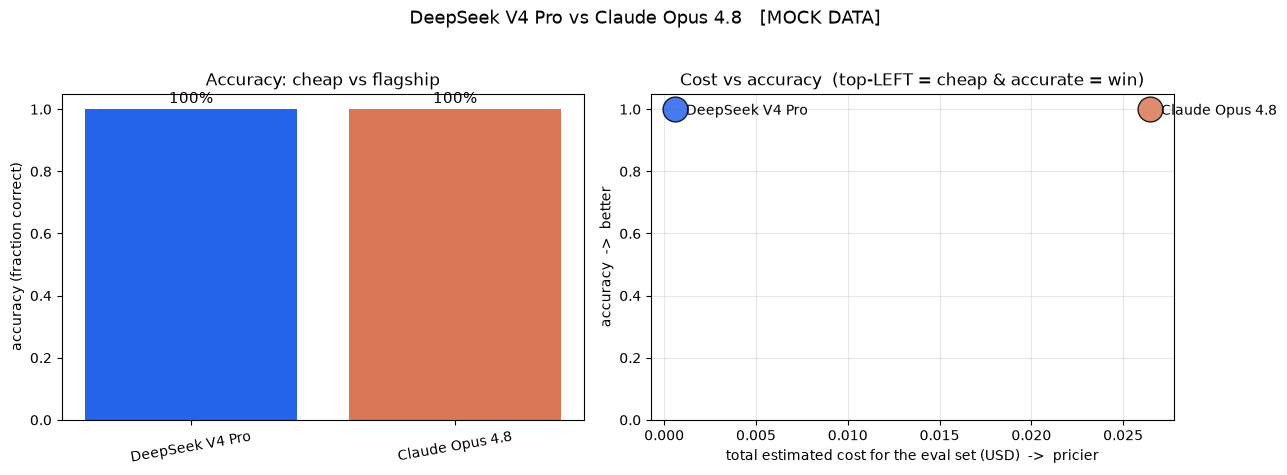

In [11]:
colors = {CHEAP_KEY: "#2563eb", FLAGSHIP_KEY: "#d97757"}
bar_colors = [colors.get(k, "#64748b") for k in agg["model_key"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# (1) accuracy bars -----------------------------------------------------------
axes[0].bar(agg["model"], agg["accuracy"], color=bar_colors)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("accuracy (fraction correct)")
axes[0].set_title("Accuracy: cheap vs flagship")
for x, v in enumerate(agg["accuracy"]):
    axes[0].text(x, v + 0.02, f"{v:.0%}", ha="center", fontsize=11)
axes[0].tick_params(axis="x", rotation=10)

# (2) cost vs accuracy scatter ------------------------------------------------
for _, row in agg.iterrows():
    axes[1].scatter(row["total_cost_usd"], row["accuracy"],
                    s=320, color=colors.get(row["model_key"], "#64748b"),
                    edgecolors="black", alpha=0.85, zorder=3)
    axes[1].annotate(row["model"], (row["total_cost_usd"], row["accuracy"]),
                     xytext=(8, -4), textcoords="offset points", fontsize=10)
axes[1].set_xlabel("total estimated cost for the eval set (USD)  ->  pricier")
axes[1].set_ylabel("accuracy  ->  better")
axes[1].set_title("Cost vs accuracy  (top-LEFT = cheap & accurate = win)")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

fig.suptitle(f"DeepSeek V4 Pro vs {flag['model']}"
             + ("   [MOCK DATA]" if FULLY_MOCK else "   [live/mixed]"),
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 12 · Reproducibility check (mock mode is bit-exact)

To make the "repeatable, not anecdotal" point concrete: re-running the **mock** pipeline produces **identical** results because everything is seeded. (A live run would be *close* but not identical — see §4.)

In [12]:
def mock_run_signature():
    sig = []
    for key in CONTENDERS:
        for task in EVAL_SET:
            out = run_agent_mock(key, task)
            sig.append((key, task["id"], round(out["latency_s"], 3),
                        out["in_tokens"], out["out_tokens"]))
    return hashlib.sha256(repr(sig).encode()).hexdigest()[:16]

s1 = mock_run_signature()
s2 = mock_run_signature()
print("Mock run signature (pass 1):", s1)
print("Mock run signature (pass 2):", s2)
print("-" * 60)
print("Identical across re-runs?  ", s1 == s2,
      "  <- seeded mock is reproducible by construction")

Mock run signature (pass 1): a090238b6a044570
Mock run signature (pass 2): a090238b6a044570
------------------------------------------------------------
Identical across re-runs?   True   <- seeded mock is reproducible by construction


## 13 · Recap & caveats

**Methodology (what made this a *disciplined* vibe-check):**
1. **A fixed, narrow task** with a small **fixed-order eval set** (10 prompts, sorted by id, never shuffled).
2. **An LLM-as-judge** with a strict 0/1 rubric, reused from notebook 07, so "correct" isn't decided by gut feeling.
3. **Seeds + `temperature=0`** everywhere they're accepted (Python, NumPy, OpenAI/DeepSeek `seed=`), plus the judge pinned to `temperature=0`.
4. **An editable cost table** so the cost comparison is explicit and updatable.

**The cost takeaway:** on a *specific narrow task*, the cheap model (`deepseek-v4-pro`) matched the bulk of the flagship's accuracy at a small fraction of the cost. The right default is **per-task selection**, not "always reach for the most expensive model."

**Caveats — read before you trust a vibe-check:**
- Hosted models are **not bit-exact** even at `temperature=0` + seed (FP non-determinism, batching, MoE routing, silent model updates). Seeds *shrink* variance; they don't remove it.
- **10 prompts is tiny.** A real decision wants dozens-to-hundreds of cases, ideally with confidence intervals or repeated trials.
- **The judge is itself a model** and can be wrong or biased; spot-check its grades.
- **Cheap-matches-flagship is task-specific.** It holds for narrow, well-specified tasks; it often *fails* on long-horizon agentic or frontier-difficulty reasoning. Re-run this harness on **your** task before generalizing.
- The pricing here is a **placeholder** — replace `COST_PER_MTOK` with live numbers.

**To extend:** swap in your own prompts in `EVAL_SET`, add more contenders from `MODELS`, run multiple trials per prompt to estimate variance, and turn on real keys to replace the mock path.